# Train TabR dari POC-ABS flatten ordered v14

- sumber: `output/apex/features/poc_abs_flatten_ordered.xlsx`
- semua row frame dipakai sebagai sampel
- external test: 20 `event_clip` tiap label
- output run: `output/apex/train/t1`, `t2`, dst
- tambah hyperparameter tuning untuk model TabR


## v14 hyperparameter tuning\n

Internal validation tetap di-split berdasarkan `event_clip`, lalu dilakukan tuning beberapa kombinasi hyperparameter sebelum final evaluasi internal dan external.

In [1]:
import os
import re
import sys
from pathlib import Path

ROOT = Path.cwd().resolve()
if ROOT.name == 'preprocess-anxiety':
    ROOT = ROOT.parent
os.chdir(ROOT)
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

print(f'Project root: {ROOT}')


Project root: /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st


In [2]:
import random

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import optuna
import pandas as pd
import seaborn as sns
import torch
from joblib import dump
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    precision_recall_fscore_support,
)
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from torch.utils.data import DataLoader, TensorDataset

import pytorch_lightning as pl
from pytorch_lightning.callbacks import EarlyStopping, ModelCheckpoint
from pytorch_lightning.loggers import CSVLogger, TensorBoardLogger

from core.data_module import TabRDataModule
from core.TabR import LitTabR


In [3]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
N_TUNING_TRIALS = 20
TUNING_TIMEOUT = None

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'n_tuning_trials': N_TUNING_TRIALS, 'tuning_timeout': TUNING_TIMEOUT})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'n_tuning_trials': 20, 'tuning_timeout': None}


In [4]:
FEATURES_PATH = ROOT / 'output/apex/features/poc_abs_flatten_ordered.xlsx'
TRAIN_ROOT = ROOT / 'output/apex/train'
N_EXTERNAL_PER_LABEL = 20
BATCH_SIZE = 128
MAX_EPOCHS = 50
RANDOM_SEED = 42
THRESHOLD = 0.5
LR = 3e-4
FREEZE_CONTEXT_EPOCH = MAX_EPOCHS // 4
M_NEIGHBORS = 8
EARLY_STOPPING_PATIENCE = 6

TRAIN_ROOT.mkdir(parents=True, exist_ok=True)
print(FEATURES_PATH)
print(TRAIN_ROOT)
print({'lr': LR, 'freeze_context_epoch': FREEZE_CONTEXT_EPOCH, 'm': M_NEIGHBORS, 'patience': EARLY_STOPPING_PATIENCE})


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/features/poc_abs_flatten_ordered.xlsx
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train
{'lr': 0.0003, 'freeze_context_epoch': 12, 'm': 8, 'patience': 6}


In [5]:
def get_next_train_dir(train_root: Path) -> Path:
    existing = []
    for path in train_root.iterdir():
        if path.is_dir() and re.fullmatch(r't\d+', path.name):
            existing.append(int(path.name[1:]))
    next_idx = max(existing, default=0) + 1
    out_dir = train_root / f't{next_idx}'
    out_dir.mkdir(parents=True, exist_ok=False)
    return out_dir


def plot_lightning_metrics(metrics_csv):
    import pandas as pd
    import matplotlib.pyplot as plt

    df = pd.read_csv(metrics_csv)

    if 'epoch' not in df.columns:
        raise ValueError('Kolom epoch tidak ada')

    df_epoch = (
        df.sort_values('step')
          .groupby('epoch', as_index=False)
          .last()
    )

    plt.figure()

    if 'train_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_loss'], label='Train Loss')

    if 'val_loss' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_loss'], label='Val Loss')

    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title('Training vs Validation Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure()

    if 'train_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['train_acc'], label='Train Accuracy')

    if 'val_acc' in df_epoch:
        plt.plot(df_epoch['epoch'], df_epoch['val_acc'], label='Val Accuracy')

    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.title('Training vs Validation Accuracy')
    plt.legend()
    plt.grid(True)
    plt.show()


def visualize_results(model_dir, class_names=('anxiety_rendah', 'anxiety_tinggi')):
    model_dir = str(model_dir).rstrip('/')

    cm_files = {
        'Internal': os.path.join(model_dir, 'cm_internal.png'),
        'External': os.path.join(model_dir, 'cm_external.png'),
    }

    report_files = {
        'Internal': os.path.join(model_dir, 'report_internal.csv'),
        'External': os.path.join(model_dir, 'report_external.csv'),
    }

    for name, path in cm_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        img = mpimg.imread(path)
        plt.figure(figsize=(5, 4))
        plt.imshow(img)
        plt.axis('off')
        plt.title(f'TabR {name} Confusion Matrix')
        plt.show()

    for name, path in report_files.items():
        if not os.path.exists(path):
            print(f'Missing {path}')
            continue

        df = pd.read_csv(path, index_col=0)
        print(f'\n=== {name.upper()} CLASSIFICATION REPORT ===')
        print(df)


def evaluate_model(model, loader, threshold=0.5):
    model.eval()
    device = model.get_device()
    y_true, y_pred = [], []

    with torch.no_grad():
        for x, y in loader:
            x = x.to(device)
            y = y.to(device)
            logits = model(x)
            prob = torch.softmax(logits, dim=1)[:, 1]
            preds = (prob > threshold).long()
            y_true.extend(y.cpu().numpy())
            y_pred.extend(preds.cpu().numpy())

    acc = accuracy_score(y_true, y_pred)
    prec, rec, f1, sup = precision_recall_fscore_support(y_true, y_pred, average=None)

    return {
        'accuracy': acc,
        'precision': prec,
        'recall': rec,
        'f1': f1,
        'support': sup,
        'cm': confusion_matrix(y_true, y_pred),
        'report': classification_report(y_true, y_pred, output_dict=True),
    }


def save_confusion_matrix(cm, labels, out_path, title):
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=labels, yticklabels=labels, cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('True')
    plt.title(title)
    plt.tight_layout()
    plt.savefig(out_path)
    plt.close()


def balance_context_by_label(X, y, max_per_class=None):
    idx0 = (y == 0).nonzero(as_tuple=True)[0]
    idx1 = (y == 1).nonzero(as_tuple=True)[0]

    n = min(len(idx0), len(idx1))
    if max_per_class is not None:
        n = min(n, max_per_class)

    idx0 = idx0[torch.randperm(len(idx0))[:n]]
    idx1 = idx1[torch.randperm(len(idx1))[:n]]

    idx = torch.cat([idx0, idx1])
    idx = idx[torch.randperm(len(idx))]
    return X[idx], y[idx]


In [6]:
random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.set_float32_matmul_precision('medium')

df = pd.read_excel(FEATURES_PATH)
print(df.shape)
df[['phase', 'label', 'participant', 'clip', 'event_clip', 'frame']].head()


(57656, 405)


,phase,label,participant,clip,event_clip,frame
0,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,2
1,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,3
2,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,4
3,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,5
4,before,anxiety_tinggi,aaisyah_nursalsabiil_ni_patriarti,answer_1_15d591ce-051a-47f2-ac38-367c1e6189c7_sec,event_00054-00095,6


In [7]:
label_map = {
    'anxiety_rendah': 0,
    'anxiety_tinggi': 1,
}

df = df[df['label'].isin(label_map)].copy()
df['target'] = df['label'].map(label_map)
df['event_id'] = df['phase'].astype(str) + '||' + df['participant'].astype(str) + '||' + df['question'].astype(str) + '||' + df['clip'].astype(str) + '||' + df['event_clip'].astype(str)

event_table = df[['event_id', 'label', 'target', 'phase', 'participant', 'question', 'clip', 'event_clip']].drop_duplicates().reset_index(drop=True)
event_table.shape


(2763, 8)

In [8]:
def balanced_external_events(event_table: pd.DataFrame, n_per_label: int, seed: int = 42) -> set[str]:
    rng = random.Random(seed)
    selected_ids: list[str] = []

    for label_name in ['anxiety_rendah', 'anxiety_tinggi']:
        label_df = event_table[event_table['label'] == label_name].copy()
        if label_df.empty:
            continue

        picked_rows = []
        used_ids = set()

        participant_groups = []
        for participant, part_df in label_df.groupby('participant', sort=True):
            part_df = part_df.sort_values(['phase', 'question', 'clip', 'event_clip'], kind='stable')
            phase_groups = []
            for phase, phase_df in part_df.groupby('phase', sort=True):
                phase_groups.append(phase_df.to_dict('records'))
            participant_groups.append((participant, phase_groups))

        while len(picked_rows) < n_per_label:
            progress = False
            for _participant, phase_groups in participant_groups:
                for records in phase_groups:
                    while records and records[0]['event_id'] in used_ids:
                        records.pop(0)
                    if not records:
                        continue
                    row = records.pop(0)
                    picked_rows.append(row)
                    used_ids.add(row['event_id'])
                    progress = True
                    if len(picked_rows) >= n_per_label:
                        break
                if len(picked_rows) >= n_per_label:
                    break
            if not progress:
                break

        if len(picked_rows) < n_per_label:
            remaining = label_df[~label_df['event_id'].isin(used_ids)].sort_values(['participant', 'phase', 'question', 'clip', 'event_clip'], kind='stable')
            for row in remaining.to_dict('records'):
                picked_rows.append(row)
                used_ids.add(row['event_id'])
                if len(picked_rows) >= n_per_label:
                    break

        selected_ids.extend([row['event_id'] for row in picked_rows[:n_per_label]])

    return set(selected_ids)


external_event_ids = balanced_external_events(event_table, N_EXTERNAL_PER_LABEL, seed=RANDOM_SEED)
df_external = df[df['event_id'].isin(external_event_ids)].copy()
df_train_all = df[~df['event_id'].isin(external_event_ids)].copy()

print('External events:', len(external_event_ids))
print('External rows:', df_external.shape)
print('Train rows:', df_train_all.shape)
print(event_table[event_table['event_id'].isin(external_event_ids)]['label'].value_counts().to_dict())
print(event_table[event_table['event_id'].isin(external_event_ids)].groupby('label')['participant'].nunique())
print(pd.crosstab(event_table[event_table['event_id'].isin(external_event_ids)]['phase'], event_table[event_table['event_id'].isin(external_event_ids)]['label']))


External events: 40
External rows: (906, 407)
Train rows: (56750, 407)
{'anxiety_tinggi': 20, 'anxiety_rendah': 20}
label
anxiety_rendah    15
anxiety_tinggi    14
Name: participant, dtype: int64
label   anxiety_rendah  anxiety_tinggi
phase                                 
after               14               7
before               6              13


In [9]:
meta_cols = [
    'phase', 'condition', 'label', 'participant', 'participant_raw', 'question', 'question_no',
    'sample', 'clip', 'event_clip', 'event_no', 'clip_path', 'frame', 'target', 'event_id',
]
feature_cols = [c for c in df.columns if c not in meta_cols]
print('n_features =', len(feature_cols))
feature_cols[:10]


n_features = 392


['mulut_x1',
 'mulut_y1',
 'mulut_t1',
 'mulut_m1',
 'mulut_x2',
 'mulut_y2',
 'mulut_t2',
 'mulut_m2',
 'mulut_x3',
 'mulut_y3']

In [10]:
train_events = event_table[~event_table['event_id'].isin(external_event_ids)].copy()
train_event_ids, val_event_ids = train_test_split(
    train_events['event_id'],
    test_size=0.2,
    stratify=train_events['target'],
    random_state=RANDOM_SEED,
)

train_event_ids = set(train_event_ids.tolist())
val_event_ids = set(val_event_ids.tolist())

df_tr = df_train_all[df_train_all['event_id'].isin(train_event_ids)].copy()
df_val = df_train_all[df_train_all['event_id'].isin(val_event_ids)].copy()

imputer = SimpleImputer(strategy='mean')
scaler = StandardScaler()

X_train_np = scaler.fit_transform(imputer.fit_transform(df_tr[feature_cols]))
X_val_np = scaler.transform(imputer.transform(df_val[feature_cols]))
X_ext_np = scaler.transform(imputer.transform(df_external[feature_cols]))

X_train = torch.tensor(X_train_np, dtype=torch.float32)
y_train = torch.tensor(df_tr['target'].values, dtype=torch.long)
X_val = torch.tensor(X_val_np, dtype=torch.float32)
y_val = torch.tensor(df_val['target'].values, dtype=torch.long)
X_ext = torch.tensor(X_ext_np, dtype=torch.float32)
y_ext = torch.tensor(df_external['target'].values, dtype=torch.long)

ctx_train_X, ctx_train_y = balance_context_by_label(X_train, y_train)
ctx_val_X, ctx_val_y = X_val, y_val

print('train events:', len(train_event_ids))
print('val events:', len(val_event_ids))
print(X_train.shape, X_val.shape, X_ext.shape)


train events: 2178
val events: 545
torch.Size([44977, 392]) torch.Size([11773, 392]) torch.Size([906, 392])


In [11]:
def fit_tabr_trial(out_dir: Path, params: dict):
    dm = TabRDataModule(
        X_train, y_train,
        X_val, y_val,
        ctx_train_X, ctx_train_y,
        ctx_val_X, ctx_val_y,
        batch_size=BATCH_SIZE,
    )

    model = LitTabR(
        in_dim=len(feature_cols),
        num_classes=2,
        d=params['d_model'],
        freeze_context_epoch=params['freeze_context_epoch'],
        m=params['m_neighbors'],
        lr=params['lr'],
        dropout=params['dropout'],
    )

    checkpoint_cb = ModelCheckpoint(
        dirpath=str(out_dir),
        filename='best',
        monitor='val_loss',
        mode='min',
        save_top_k=1,
    )

    loggers = [
        CSVLogger(save_dir=str(out_dir), name='tabr_logs'),
        TensorBoardLogger(save_dir=str(out_dir), name='tb_logs'),
    ]

    trainer = pl.Trainer(
        max_epochs=MAX_EPOCHS,
        accelerator='gpu' if torch.cuda.is_available() else 'cpu',
        devices=1,
        logger=loggers,
        log_every_n_steps=1,
        default_root_dir=str(out_dir),
        callbacks=[
            EarlyStopping(monitor='val_loss', patience=params['patience'], mode='min'),
            checkpoint_cb,
        ],
        enable_progress_bar=False,
        enable_model_summary=False,
    )

    trainer.fit(model, datamodule=dm)

    best_ckpt = checkpoint_cb.best_model_path or str(out_dir / 'best.ckpt')
    best_score = checkpoint_cb.best_model_score.item() if checkpoint_cb.best_model_score is not None else None
    if checkpoint_cb.best_model_path:
        model = LitTabR.load_from_checkpoint(checkpoint_cb.best_model_path, weights_only=False).to(model.get_device())
    trainer.save_checkpoint(str(out_dir / 'last.ckpt'))

    model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    model.set_default_context(ctx_train_X, ctx_train_y)

    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

    model.eval()
    model.set_context(ctx_train_X, ctx_train_y)
    res_int = evaluate_model(model, val_loader, threshold=THRESHOLD)
    res_ext = evaluate_model(model, ext_loader, threshold=THRESHOLD)

    trial_summary = {
        **params,
        'best_checkpoint': best_ckpt,
        'best_val_loss': best_score,
        'internal_accuracy': res_int['accuracy'],
        'external_accuracy': res_ext['accuracy'],
    }

    pd.DataFrame([trial_summary]).to_csv(out_dir / 'trial_summary.csv', index=False)
    return model, res_int, res_ext, trial_summary


def suggest_tabr_params(trial: optuna.Trial) -> dict:
    return {
        'lr': trial.suggest_float('lr', 1e-4, 1e-3, log=True),
        'freeze_context_epoch': trial.suggest_int('freeze_context_epoch', 6, 16),
        'm_neighbors': trial.suggest_categorical('m_neighbors', [4, 8, 16, 32]),
        'dropout': trial.suggest_float('dropout', 0.05, 0.30),
        'patience': trial.suggest_int('patience', 4, 10),
        'd_model': trial.suggest_categorical('d_model', [64, 128, 256]),
    }


def train_tabr_with_tuning(out_dir: Path, n_trials: int, timeout=None):
    trial_rows = []

    def objective(trial: optuna.Trial):
        params = suggest_tabr_params(trial)
        trial_dir = out_dir / f'trial_{trial.number:03d}'
        trial_dir.mkdir(parents=True, exist_ok=False)

        _model, res_int, res_ext, summary = fit_tabr_trial(trial_dir, params)
        summary = {'trial': trial.number, **summary}
        trial_rows.append(summary)

        trial.set_user_attr('summary', summary)
        trial.set_user_attr('internal_accuracy', res_int['accuracy'])
        trial.set_user_attr('external_accuracy', res_ext['accuracy'])
        return summary['best_val_loss'] if summary['best_val_loss'] is not None else float('inf')

    study = optuna.create_study(
        direction='minimize',
        sampler=optuna.samplers.TPESampler(seed=RANDOM_SEED),
        pruner=optuna.pruners.MedianPruner(n_startup_trials=5, n_warmup_steps=0),
    )
    study.optimize(objective, n_trials=n_trials, timeout=timeout)

    trial_df = pd.DataFrame(trial_rows).sort_values(['best_val_loss', 'internal_accuracy'], ascending=[True, False], na_position='last')
    trial_df.to_csv(out_dir / 'tuning_results.csv', index=False)

    best_summary = study.best_trial.user_attrs['summary']
    best_trial_dir = out_dir / f"trial_{study.best_trial.number:03d}"

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    best_model = LitTabR.load_from_checkpoint(best_summary['best_checkpoint'], weights_only=False).to(device)
    best_model.set_preprocessor(imputer=imputer, scaler=scaler, feature_cols=feature_cols)
    best_model.set_default_context(ctx_train_X, ctx_train_y)

    val_loader = DataLoader(TensorDataset(X_val, y_val), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)
    ext_loader = DataLoader(TensorDataset(X_ext, y_ext), batch_size=BATCH_SIZE, shuffle=False, num_workers=8)

    best_model.eval()
    best_model.set_context(ctx_train_X, ctx_train_y)
    best_results = {
        'internal': evaluate_model(best_model, val_loader, threshold=THRESHOLD),
        'external': evaluate_model(best_model, ext_loader, threshold=THRESHOLD),
    }

    dump(imputer, out_dir / 'imputer.joblib')
    dump(scaler, out_dir / 'scaler.joblib')
    dump(feature_cols, out_dir / 'feature_cols.joblib')
    dump((ctx_train_X.cpu(), ctx_train_y.cpu()), out_dir / 'context.joblib')
    df_tr.to_csv(out_dir / 'train_split.csv', index=False)
    df_val.to_csv(out_dir / 'val_split.csv', index=False)
    df_external.to_csv(out_dir / 'external_test.csv', index=False)
    pd.DataFrame([{
        **best_summary,
        'best_trial_number': study.best_trial.number,
        'best_trial_dir': str(best_trial_dir),
    }]).to_csv(out_dir / 'run_config.csv', index=False)
    pd.DataFrame([{
        **best_summary,
        'best_trial_number': study.best_trial.number,
        'best_trial_dir': str(best_trial_dir),
    }]).to_csv(out_dir / 'best_trial.csv', index=False)

    pd.DataFrame(best_results['internal']['report']).transpose().to_csv(out_dir / 'report_internal.csv')
    pd.DataFrame(best_results['external']['report']).transpose().to_csv(out_dir / 'report_external.csv')

    save_confusion_matrix(best_results['internal']['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_internal.png', 'TabR Internal Confusion Matrix')
    save_confusion_matrix(best_results['external']['cm'], ['anxiety_rendah', 'anxiety_tinggi'], out_dir / 'cm_external.png', 'TabR External Confusion Matrix')

    pd.DataFrame({
        'split': ['internal', 'external'],
        'accuracy': [best_results['internal']['accuracy'], best_results['external']['accuracy']],
    }).to_csv(out_dir / 'summary_metrics.csv', index=False)

    return best_model, best_results, trial_df, best_summary, study



In [12]:
OUT_DIR = get_next_train_dir(TRAIN_ROOT)
print(OUT_DIR)
model, results, tuning_results, best_config, study = train_tabr_with_tuning(OUT_DIR, N_TUNING_TRIALS, TUNING_TIMEOUT)
tuning_results


[I 2026-03-24 12:22:42,560] A new study created in memory with name: no-name-7a20bbc0-793b-431d-9e68-7cdc37f7ba5f
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t34


/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t34/trial_000 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation context frozen & FAISS built


`weights_only` was not set, defaulting to `False`.
[I 2026-03-24 12:23:59,222] Trial 0 finished with value: 0.5324950814247131 and parameters: {'lr': 0.00023688639503640813, 'freeze_context_epoch': 16, 'm_neighbors': 4, 'dropout': 0.06452090304204987, 'patience': 10, 'd_model': 128}. Best is trial 0 with value: 0.5324950814247131.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t34/trial_001 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


...

Validation context frozen & FAISS built
Context frozen & FAISS built


`weights_only` was not set, defaulting to `False`.
[I 2026-03-24 12:50:48,532] Trial 18 finished with value: 0.48945584893226624 and parameters: {'lr': 0.00030804544031273095, 'freeze_context_epoch': 9, 'm_neighbors': 16, 'dropout': 0.2611279809520548, 'patience': 9, 'd_model': 256}. Best is trial 14 with value: 0.46399369835853577.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
/home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/.venv/lib/python3.12/site-packages/pytorch_lightning/callbacks/model_checkpoint.py:881: Checkpoint directory /home/ryuko/Documents/Codes/Python/Skripsi/Convat-1st/output/apex/train/t34/trial_019 exists and is not empty.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Validation context frozen & FAISS built


`weights_only` was not set, defaulting to `False`.
[I 2026-03-24 12:51:34,585] Trial 19 finished with value: 0.5259424448013306 and parameters: {'lr': 0.0006293829689451544, 'freeze_context_epoch': 10, 'm_neighbors': 8, 'dropout': 0.2064994812066171, 'patience': 5, 'd_model': 128}. Best is trial 14 with value: 0.46399369835853577.


,trial,lr,freeze_context_epoch,m_neighbors,dropout,patience,d_model,best_checkpoint,best_val_loss,internal_accuracy,external_accuracy
14,14,0.000522,12,8,0.158584,10,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.463994,0.694895,0.720751
16,16,0.000329,11,8,0.207571,10,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.479093,0.661344,0.701987
10,10,0.000478,13,8,0.112406,10,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.481272,0.674679,0.679912
11,11,0.000478,13,8,0.107875,10,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.485783,0.696849,0.711921
18,18,0.000308,9,16,0.261128,9,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.489456,0.673405,0.695364
12,12,0.000448,13,8,0.126243,10,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.509455,0.703729,0.715232
6,6,0.000138,14,8,0.051381,9,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.513287,0.686146,0.690949
13,13,0.000402,12,8,0.102449,8,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.514667,0.684617,0.672185
15,15,0.000588,8,8,0.153513,8,256,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.520009,0.678587,0.703091
19,19,0.000629,10,8,0.206499,5,128,/home/ryuko/Documents/Codes/Python/Skripsi/Con...,0.525942,0.685297,0.682119


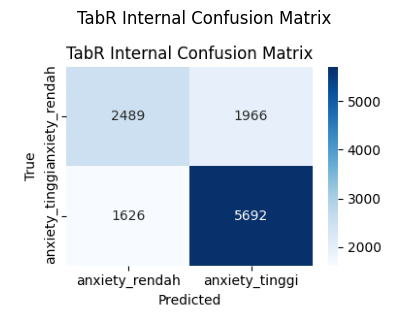

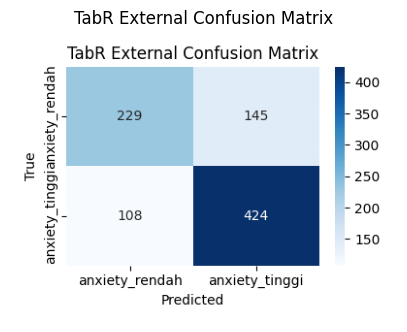


=== INTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score       support
0              0.604860  0.558698  0.580863   4455.000000
1              0.743275  0.777808  0.760150   7318.000000
accuracy       0.694895  0.694895  0.694895      0.694895
macro avg      0.674068  0.668253  0.670507  11773.000000
weighted avg   0.690898  0.694895  0.692306  11773.000000

=== EXTERNAL CLASSIFICATION REPORT ===
              precision    recall  f1-score     support
0              0.679525  0.612299  0.644163  374.000000
1              0.745167  0.796992  0.770209  532.000000
accuracy       0.720751  0.720751  0.720751    0.720751
macro avg      0.712346  0.704646  0.707186  906.000000
weighted avg   0.718070  0.720751  0.718177  906.000000


In [13]:
visualize_results(OUT_DIR)


In [15]:
print('BEST CONFIG')
print(pd.DataFrame([best_config]))
print('\nTUNING RESULTS (TOP 10)')
print(tuning_results.head(10))
print('\nSUMMARY METRICS')
print(pd.DataFrame({
    'split': ['internal', 'external'],
    'accuracy': [results['internal']['accuracy'], results['external']['accuracy']],
}))
print('\nINTERNAL REPORT')
print(pd.DataFrame(results['internal']['report']).transpose())
print('\nEXTERNAL REPORT')
print(pd.DataFrame(results['external']['report']).transpose())


BEST CONFIG
   trial        lr  freeze_context_epoch  m_neighbors   dropout  patience  \
0     14  0.000522                    12            8  0.158584        10   

   d_model                                    best_checkpoint  best_val_loss  \
0      256  /home/ryuko/Documents/Codes/Python/Skripsi/Con...       0.463994   

   internal_accuracy  external_accuracy  
0           0.694895           0.720751  

TUNING RESULTS (TOP 10)
    trial        lr  freeze_context_epoch  m_neighbors   dropout  patience  \
14     14  0.000522                    12            8  0.158584        10   
16     16  0.000329                    11            8  0.207571        10   
10     10  0.000478                    13            8  0.112406        10   
11     11  0.000478                    13            8  0.107875        10   
18     18  0.000308                     9           16  0.261128         9   
12     12  0.000448                    13            8  0.126243        10   
6       6  0.0001